In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Proyecto_PINN_HRF")

DATA_ROOT = PROJECT_ROOT / "data" / "raw"
SUBJECT_ID = "100206"

RESULTS_DIR = (
    DATA_ROOT
    / SUBJECT_ID
    / "MNINonLinear"
    / "Results"
)

MOTOR_LR_DIR = RESULTS_DIR / "tfMRI_MOTOR_LR"
MOTOR_RL_DIR = RESULTS_DIR / "tfMRI_MOTOR_RL"

print("Proyecto:", PROJECT_ROOT)
print("MOTOR LR existe:", MOTOR_LR_DIR.exists())
print("MOTOR RL existe:", MOTOR_RL_DIR.exists())

Proyecto: /content/drive/MyDrive/Proyecto_PINN_HRF
MOTOR LR existe: True
MOTOR RL existe: True


In [10]:
fmri_lr = MOTOR_LR_DIR / "tfMRI_MOTOR_LR_hp0_clean_rclean_tclean.nii.gz"
fmri_rl = MOTOR_RL_DIR / "tfMRI_MOTOR_RL_hp0_clean_rclean_tclean.nii.gz"

events_lr = MOTOR_LR_DIR / "EVs"
events_rl = MOTOR_RL_DIR / "EVs"

print("fMRI LR:", fmri_lr.exists(), fmri_lr)
print("fMRI RL:", fmri_rl.exists(), fmri_rl)
print("EVs LR:", events_lr.exists())
print("EVs RL:", events_rl.exists())

fMRI LR: True /content/drive/MyDrive/Proyecto_PINN_HRF/data/raw/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/tfMRI_MOTOR_LR_hp0_clean_rclean_tclean.nii.gz
fMRI RL: True /content/drive/MyDrive/Proyecto_PINN_HRF/data/raw/100206/MNINonLinear/Results/tfMRI_MOTOR_RL/tfMRI_MOTOR_RL_hp0_clean_rclean_tclean.nii.gz
EVs LR: True
EVs RL: True


In [11]:
print("Eventos LR:")
for archivo in sorted(events_lr.glob("*.txt")):
    print(" -", archivo.name)

print("\nEventos RL:")
for archivo in sorted(events_rl.glob("*.txt")):
    print(" -", archivo.name)

Eventos LR:
 - Sync.txt
 - cue.txt
 - lf.txt
 - lh.txt
 - rf.txt
 - rh.txt
 - t.txt

Eventos RL:
 - Sync.txt
 - cue.txt
 - lf.txt
 - lh.txt
 - rf.txt
 - rh.txt
 - t.txt


In [12]:
import numpy as np
import pandas as pd
from pathlib import Path


def cargar_eventos(
    carpeta_evs: Path,
    condicion: str,
) -> pd.DataFrame:
    """
    Lee un archivo de eventos del HCP.

    Cada fila contiene:
        onset [s], duración [s], amplitud

    Parameters
    ----------
    carpeta_evs:
        Ruta de la carpeta EVs.
    condicion:
        Nombre de la condición sin extensión, por ejemplo:
        'rh', 'lh', 'rf', 'lf', 't' o 'cue'.

    Returns
    -------
    pd.DataFrame
        Tabla con onset, duración, amplitud y condición.
    """
    archivo = carpeta_evs / f"{condicion}.txt"

    if not archivo.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo de eventos: {archivo}"
        )

    datos = np.loadtxt(archivo, ndmin=2)

    if datos.shape[1] < 3:
        raise ValueError(
            f"El archivo {archivo.name} debe tener al menos tres columnas."
        )

    eventos = pd.DataFrame(
        datos[:, :3],
        columns=["onset_s", "duration_s", "amplitude"],
    )

    eventos["condition"] = condicion
    eventos["end_s"] = eventos["onset_s"] + eventos["duration_s"]

    return eventos

In [13]:
rh_lr = cargar_eventos(events_lr, "rh")
lh_lr = cargar_eventos(events_lr, "lh")

rh_rl = cargar_eventos(events_rl, "rh")
lh_rl = cargar_eventos(events_rl, "lh")

print("Mano derecha, corrida LR:")
display(rh_lr)

print("Mano izquierda, corrida LR:")
display(lh_lr)

print("Mano derecha, corrida RL:")
display(rh_rl)

print("Mano izquierda, corrida RL:")
display(lh_rl)

Mano derecha, corrida LR:


,onset_s,duration_s,amplitude,condition,end_s
0,11.009,12.0,1.0,rh,23.009
1,131.892,12.0,1.0,rh,143.892


Mano izquierda, corrida LR:


,onset_s,duration_s,amplitude,condition,end_s
0,71.517,12.0,1.0,lh,83.517
1,162.013,12.0,1.0,lh,174.013


Mano derecha, corrida RL:


,onset_s,duration_s,amplitude,condition,end_s
0,86.498,12.0,1.0,rh,98.498
1,162.000,12.0,1.0,rh,174.000


Mano izquierda, corrida RL:


,onset_s,duration_s,amplitude,condition,end_s
0,10.996,12.0,1.0,lh,22.996
1,116.619,12.0,1.0,lh,128.619


In [14]:
!pip install -q nibabel nilearn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [15]:
import json
import shutil
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import signal
from nilearn.maskers import NiftiSpheresMasker

In [16]:
TEMP_DATA_DIR = Path("/content/pinn_hrf_data")
TEMP_DATA_DIR.mkdir(parents=True, exist_ok=True)


def copiar_a_runtime(archivo_origen: Path) -> Path:
    """
    Copia un archivo desde Google Drive al almacenamiento temporal
    de Colab para acelerar su lectura.
    """
    archivo_destino = TEMP_DATA_DIR / archivo_origen.name

    if not archivo_destino.exists():
        print(f"Copiando {archivo_origen.name}...")
        shutil.copy2(archivo_origen, archivo_destino)
    else:
        print(f"Ya existe la copia temporal de {archivo_origen.name}")

    return archivo_destino


fmri_lr_local = copiar_a_runtime(fmri_lr)
fmri_rl_local = copiar_a_runtime(fmri_rl)

print("\nArchivo LR temporal:", fmri_lr_local)
print("Archivo RL temporal:", fmri_rl_local)

Copiando tfMRI_MOTOR_LR_hp0_clean_rclean_tclean.nii.gz...
Copiando tfMRI_MOTOR_RL_hp0_clean_rclean_tclean.nii.gz...

Archivo LR temporal: /content/pinn_hrf_data/tfMRI_MOTOR_LR_hp0_clean_rclean_tclean.nii.gz
Archivo RL temporal: /content/pinn_hrf_data/tfMRI_MOTOR_RL_hp0_clean_rclean_tclean.nii.gz


In [17]:
def inspeccionar_nifti(ruta_nifti: Path, nombre_corrida: str) -> dict:
    """
    Lee el encabezado de un archivo fMRI NIfTI y muestra
    sus principales características.
    """
    imagen = nib.load(str(ruta_nifti))

    if len(imagen.shape) != 4:
        raise ValueError(
            f"{nombre_corrida}: se esperaba una imagen fMRI 4D, "
            f"pero se obtuvo una forma {imagen.shape}"
        )

    zooms = imagen.header.get_zooms()
    tr = float(zooms[3])
    n_volumenes = int(imagen.shape[3])
    duracion = (n_volumenes - 1) * tr

    informacion = {
        "corrida": nombre_corrida,
        "shape": tuple(int(valor) for valor in imagen.shape),
        "voxel_size_mm": tuple(float(valor) for valor in zooms[:3]),
        "tr_s": tr,
        "n_volumenes": n_volumenes,
        "duracion_ultimo_volumen_s": duracion,
    }

    print("=" * 55)
    print(f"Corrida: {nombre_corrida}")
    print(f"Dimensiones: {informacion['shape']}")
    print(f"Tamaño de vóxel [mm]: {informacion['voxel_size_mm']}")
    print(f"TR [s]: {tr}")
    print(f"Número de volúmenes: {n_volumenes}")
    print(f"Tiempo del último volumen [s]: {duracion:.2f}")

    return informacion


info_lr = inspeccionar_nifti(fmri_lr_local, "MOTOR_LR")
info_rl = inspeccionar_nifti(fmri_rl_local, "MOTOR_RL")

Corrida: MOTOR_LR
Dimensiones: (91, 109, 91, 284)
Tamaño de vóxel [mm]: (2.0, 2.0, 2.0)
TR [s]: 0.7200000286102295
Número de volúmenes: 284
Tiempo del último volumen [s]: 203.76
Corrida: MOTOR_RL
Dimensiones: (91, 109, 91, 284)
Tamaño de vóxel [mm]: (2.0, 2.0, 2.0)
TR [s]: 0.7200000286102295
Número de volúmenes: 284
Tiempo del último volumen [s]: 203.76


In [18]:
COORDENADAS_MOTORAS = {
    "M1_izquierda": (-38.0, -22.0, 56.0),
    "M1_derecha": (38.0, -22.0, 56.0),
}

RADIO_ROI_MM = 6.0

print("Regiones motoras definidas:")
for nombre, coordenada in COORDENADAS_MOTORAS.items():
    print(f"- {nombre}: {coordenada}")

Regiones motoras definidas:
- M1_izquierda: (-38.0, -22.0, 56.0)
- M1_derecha: (38.0, -22.0, 56.0)


In [19]:
def verificar_coordenadas(
    ruta_nifti: Path,
    coordenadas: dict,
) -> pd.DataFrame:
    """
    Transforma coordenadas MNI a coordenadas de vóxel
    y verifica que se encuentren dentro del volumen.
    """
    imagen = nib.load(str(ruta_nifti))
    inversa_afine = np.linalg.inv(imagen.affine)

    registros = []

    for nombre, coordenada_mni in coordenadas.items():
        voxel = nib.affines.apply_affine(
            inversa_afine,
            coordenada_mni,
        )

        dentro = all(
            0 <= voxel[i] < imagen.shape[i]
            for i in range(3)
        )

        registros.append(
            {
                "roi": nombre,
                "mni_x": coordenada_mni[0],
                "mni_y": coordenada_mni[1],
                "mni_z": coordenada_mni[2],
                "voxel_i": voxel[0],
                "voxel_j": voxel[1],
                "voxel_k": voxel[2],
                "dentro_del_volumen": dentro,
            }
        )

    return pd.DataFrame(registros)


verificacion_roi = verificar_coordenadas(
    fmri_lr_local,
    COORDENADAS_MOTORAS,
)

display(verificacion_roi)

,roi,mni_x,mni_y,mni_z,voxel_i,voxel_j,voxel_k,dentro_del_volumen
0,M1_izquierda,-38.0,-22.0,56.0,64.0,52.0,64.0,True
1,M1_derecha,38.0,-22.0,56.0,26.0,52.0,64.0,True


In [20]:
def extraer_series_motoras(
    ruta_nifti: Path,
    nombre_corrida: str,
    coordenadas: dict,
    radio_mm: float = 6.0,
) -> tuple[pd.DataFrame, dict]:
    """
    Extrae señales BOLD desde ROIs esféricas motoras.

    La señal se expresa como cambio fraccional:

        delta_BOLD = señal / promedio - 1

    Por ejemplo, 0.01 equivale a un cambio de 1 %.
    """
    imagen = nib.load(str(ruta_nifti))

    tr = float(imagen.header.get_zooms()[3])
    n_volumenes = int(imagen.shape[3])

    nombres_roi = list(coordenadas.keys())
    semillas = [coordenadas[nombre] for nombre in nombres_roi]

    extractor = NiftiSpheresMasker(
        seeds=semillas,
        radius=radio_mm,
        detrend=False,
        standardize=False,
        t_r=tr,
        verbose=0,
    )

    señal_cruda = extractor.fit_transform(imagen)

    if señal_cruda.shape != (n_volumenes, len(semillas)):
        raise RuntimeError(
            f"Forma inesperada de la señal extraída: "
            f"{señal_cruda.shape}"
        )

    promedio = np.mean(señal_cruda, axis=0)

    if np.any(np.isclose(promedio, 0.0)):
        raise ValueError(
            "Una ROI presenta promedio cercano a cero. "
            "Debe revisarse su ubicación."
        )

    # Cambio fraccional respecto de la señal promedio
    señal_fraccional = señal_cruda / promedio - 1.0

    # Eliminación de tendencia lineal sin estandarizar
    señal_fraccional = signal.clean(
        señal_fraccional,
        detrend=True,
        standardize=False,
        t_r=tr,
        ensure_finite=True,
    )

    tiempo = np.arange(n_volumenes, dtype=float) * tr

    tabla = pd.DataFrame(
        {
            "time_s": tiempo,
            "bold_m1_left_fraction": señal_fraccional[:, 0],
            "bold_m1_right_fraction": señal_fraccional[:, 1],
        }
    )

    metadatos = {
        "run": nombre_corrida,
        "tr_s": tr,
        "n_volumes": n_volumenes,
        "roi_radius_mm": radio_mm,
        "coordinates_mni": {
            nombre: list(coordenada)
            for nombre, coordenada in coordenadas.items()
        },
        "signal_units": "fractional_BOLD_change",
    }

    return tabla, metadatos

In [21]:
bold_lr, metadata_lr = extraer_series_motoras(
    fmri_lr_local,
    "MOTOR_LR",
    COORDENADAS_MOTORAS,
    RADIO_ROI_MM,
)

bold_rl, metadata_rl = extraer_series_motoras(
    fmri_rl_local,
    "MOTOR_RL",
    COORDENADAS_MOTORAS,
    RADIO_ROI_MM,
)

print("Forma LR:", bold_lr.shape)
print("Forma RL:", bold_rl.shape)

display(bold_lr.head())
display(bold_rl.head())

/tmp/ipykernel_1152/2965415218.py:33: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  señal_cruda = extractor.fit_transform(imagen)
/tmp/ipykernel_1152/2965415218.py:33: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  señal_cruda = extractor.fit_transform(imagen)
/tmp/ipykernel_1152/2965415218.py:53: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  señal_fraccional = signal.clean(


Forma LR: (284, 3)
Forma RL: (284, 3)


/tmp/ipykernel_1152/2965415218.py:33: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  señal_cruda = extractor.fit_transform(imagen)
/tmp/ipykernel_1152/2965415218.py:53: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  señal_fraccional = signal.clean(


,time_s,bold_m1_left_fraction,bold_m1_right_fraction
0,0.00,0.003465,0.010434
1,0.72,0.000761,0.009534
2,1.44,0.000913,0.007089
3,2.16,-0.003622,0.008882
4,2.88,-0.004042,0.005946


,time_s,bold_m1_left_fraction,bold_m1_right_fraction
0,0.00,0.000081,0.007929
1,0.72,0.001843,0.002696
2,1.44,-0.002223,-0.008290
3,2.16,-0.000316,-0.006063
4,2.88,-0.004347,0.000110


In [22]:
def validar_eventos(
    eventos: pd.DataFrame,
    duracion_corrida_s: float,
    nombre: str,
) -> None:
    """
    Comprueba que los eventos estén dentro de la duración
    de la adquisición fMRI.
    """
    if eventos.empty:
        raise ValueError(f"No existen eventos para {nombre}")

    if (eventos["onset_s"] < 0).any():
        raise ValueError(f"{nombre}: existen inicios negativos")

    fuera_de_rango = eventos["end_s"] > duracion_corrida_s

    if fuera_de_rango.any():
        display(eventos.loc[fuera_de_rango])
        raise ValueError(
            f"{nombre}: existen eventos fuera de la adquisición"
        )

    print(
        f"{nombre}: {len(eventos)} eventos válidos, "
        f"entre {eventos['onset_s'].min():.3f} y "
        f"{eventos['end_s'].max():.3f} s."
    )


duracion_lr = bold_lr["time_s"].iloc[-1]
duracion_rl = bold_rl["time_s"].iloc[-1]

validar_eventos(rh_lr, duracion_lr, "rh - MOTOR_LR")
validar_eventos(lh_lr, duracion_lr, "lh - MOTOR_LR")
validar_eventos(rh_rl, duracion_rl, "rh - MOTOR_RL")
validar_eventos(lh_rl, duracion_rl, "lh - MOTOR_RL")

rh - MOTOR_LR: 2 eventos válidos, entre 11.009 y 143.892 s.
lh - MOTOR_LR: 2 eventos válidos, entre 71.517 y 174.013 s.
rh - MOTOR_RL: 2 eventos válidos, entre 86.498 y 174.000 s.
lh - MOTOR_RL: 2 eventos válidos, entre 10.996 y 128.619 s.


In [24]:
def graficar_bold_eventos(
    tabla_bold: pd.DataFrame,
    columna_bold: str,
    eventos: pd.DataFrame,
    titulo: str,
    etiqueta_evento: str,
) -> None:
    """
    Grafica la señal BOLD como porcentaje de cambio
    y superpone los bloques experimentales.
    """
    tiempo = tabla_bold["time_s"].to_numpy()
    bold_porcentaje = (
        100.0 * tabla_bold[columna_bold].to_numpy()
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        tiempo,
        bold_porcentaje,
        linewidth=1.4,
        label="Señal BOLD de la ROI",
    )

    for indice, evento in eventos.iterrows():
        plt.axvspan(
            evento["onset_s"],
            evento["end_s"],
            alpha=0.20,
            label=etiqueta_evento if indice == eventos.index[0] else None,
        )

    plt.axhline(0.0, linewidth=0.8)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Cambio BOLD [%]")
    plt.title(titulo)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

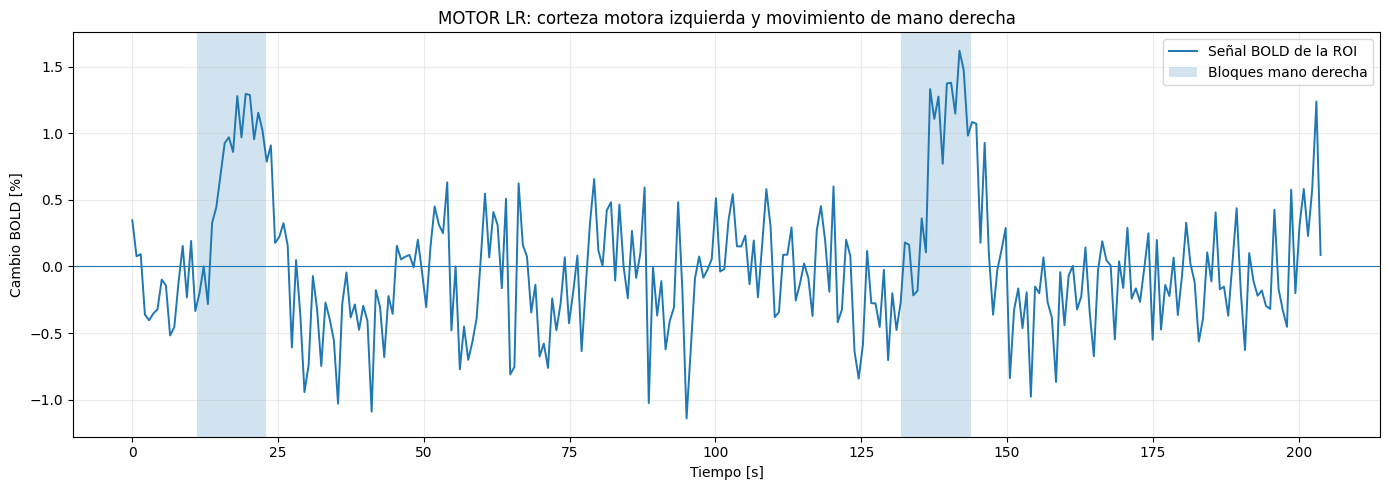

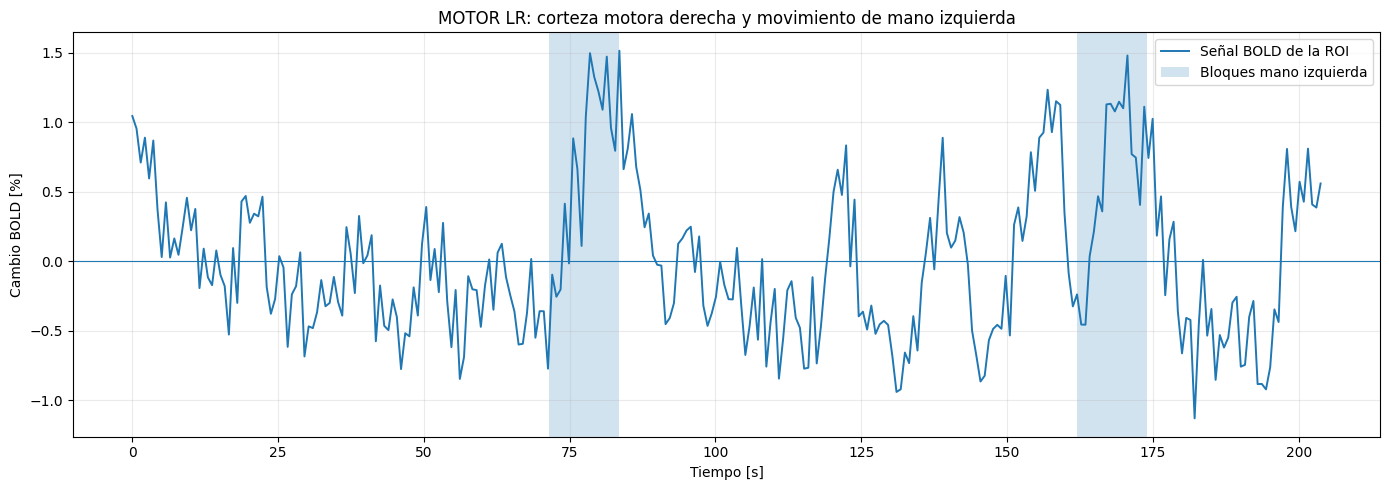

In [25]:
graficar_bold_eventos(
    bold_lr,
    "bold_m1_left_fraction",
    rh_lr,
    "MOTOR LR: corteza motora izquierda y movimiento de mano derecha",
    "Bloques mano derecha",
)

graficar_bold_eventos(
    bold_lr,
    "bold_m1_right_fraction",
    lh_lr,
    "MOTOR LR: corteza motora derecha y movimiento de mano izquierda",
    "Bloques mano izquierda",
)

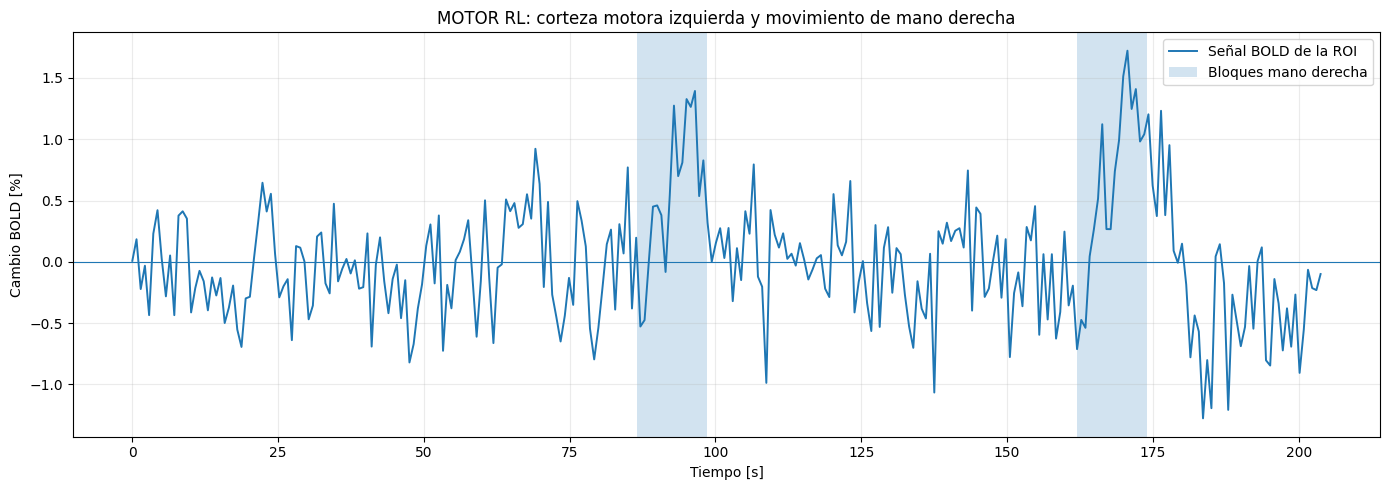

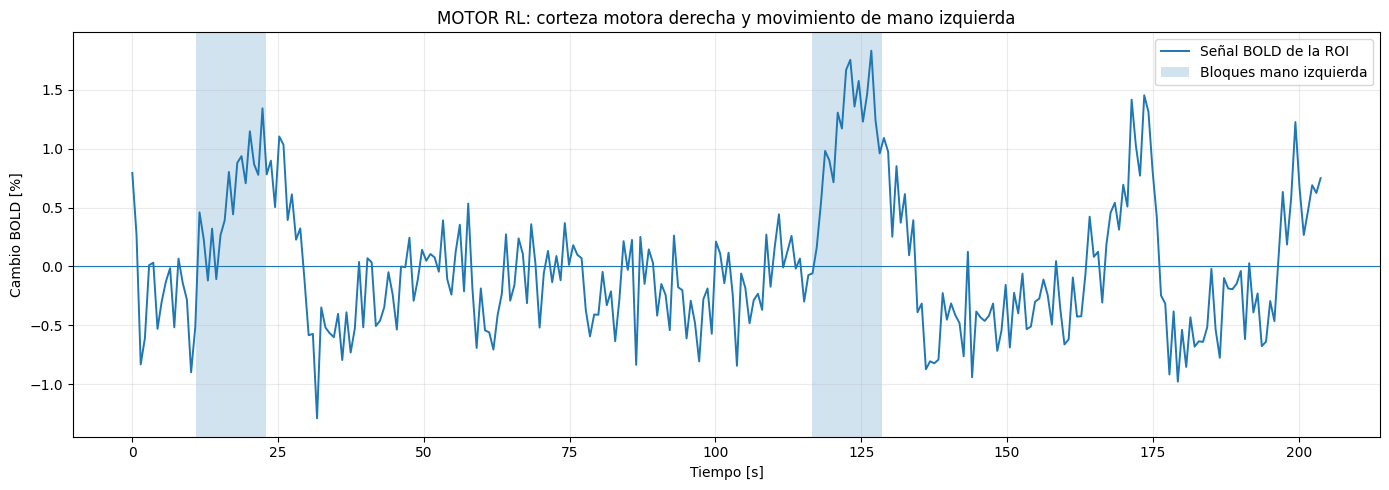

In [26]:
graficar_bold_eventos(
    bold_rl,
    "bold_m1_left_fraction",
    rh_rl,
    "MOTOR RL: corteza motora izquierda y movimiento de mano derecha",
    "Bloques mano derecha",
)

graficar_bold_eventos(
    bold_rl,
    "bold_m1_right_fraction",
    lh_rl,
    "MOTOR RL: corteza motora derecha y movimiento de mano izquierda",
    "Bloques mano izquierda",
)

In [27]:
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / SUBJECT_ID
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ruta_bold_lr = PROCESSED_DIR / "motor_lr_bilateral_bold.csv"
ruta_bold_rl = PROCESSED_DIR / "motor_rl_bilateral_bold.csv"

bold_lr.to_csv(ruta_bold_lr, index=False)
bold_rl.to_csv(ruta_bold_rl, index=False)

with open(
    PROCESSED_DIR / "motor_lr_metadata.json",
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(metadata_lr, archivo, indent=2, ensure_ascii=False)

with open(
    PROCESSED_DIR / "motor_rl_metadata.json",
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(metadata_rl, archivo, indent=2, ensure_ascii=False)

print("Archivos guardados:")
print("-", ruta_bold_lr)
print("-", ruta_bold_rl)

Archivos guardados:
- /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_lr_bilateral_bold.csv
- /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_rl_bilateral_bold.csv
